Loading data...
Series length : 4658 days
Date range    : 2012-04-01 → 2024-12-31
Price range   : ₹954 – ₹4475

── ADF Test: Original Price ──
  ADF Statistic : -2.5294
  p-value       : 0.1085
  → NON-STATIONARY ✗ (differencing needed)

── ADF Test: 1st Difference ──
  ADF Statistic : -13.3132
  p-value       : 0.0000
  → STATIONARY ✓


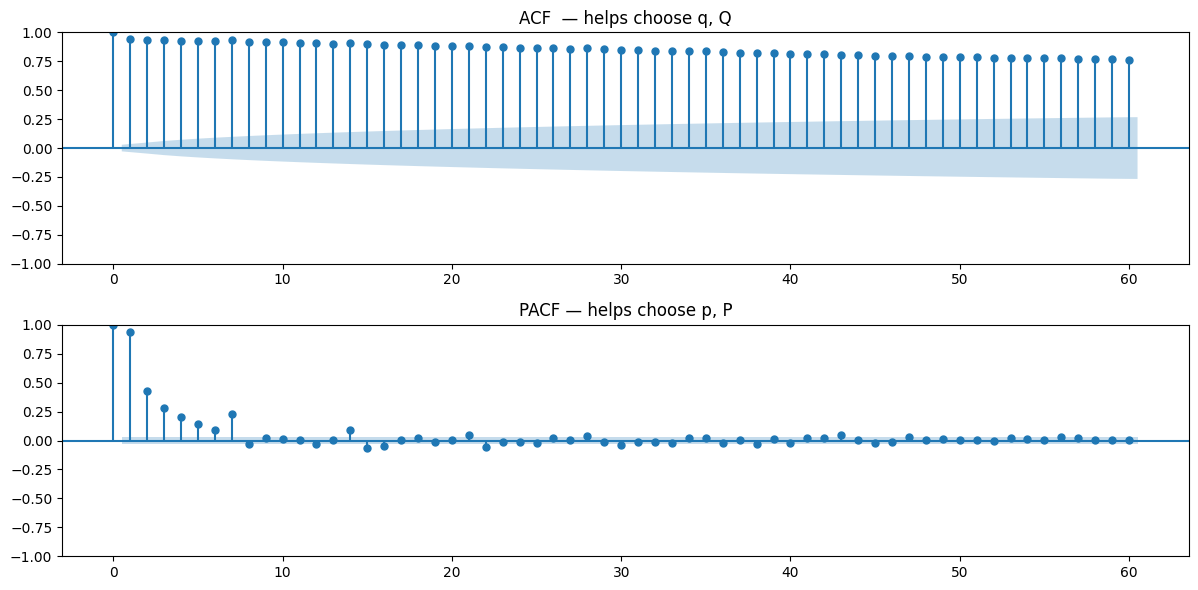


ACF/PACF plot saved → acf_pacf.png

Running grid search (seasonal period = 7)...
This may take a few minutes...

Testing 144 parameter combinations...

✓ Best SARIMA order          : (1, 0, 2)
✓ Best Seasonal order        : (1, 1, 1, 7)
✓ Best AIC                   : 54638.02

Top 5 parameter combinations:
    order     seasonal          AIC          BIC
(1, 0, 2) (1, 1, 1, 7) 54638.018639 54676.674750
(2, 0, 1) (1, 1, 1, 7) 54649.556255 54688.213658
(0, 1, 2) (1, 0, 1, 7) 54650.830210 54683.050096
(0, 1, 2) (1, 1, 1, 7) 54651.761351 54683.973700
(2, 1, 2) (1, 0, 1, 7) 54653.287724 54698.395564

Train: 3726 rows | Val: 932 rows

Fitting SARIMA(1, 0, 2)×(1, 1, 1, 7) on training data...
                                      SARIMAX Results                                      
Dep. Variable:       Mandi Modal Price (AgMarknet)   No. Observations:                 3726
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -21757.682
Date:                        

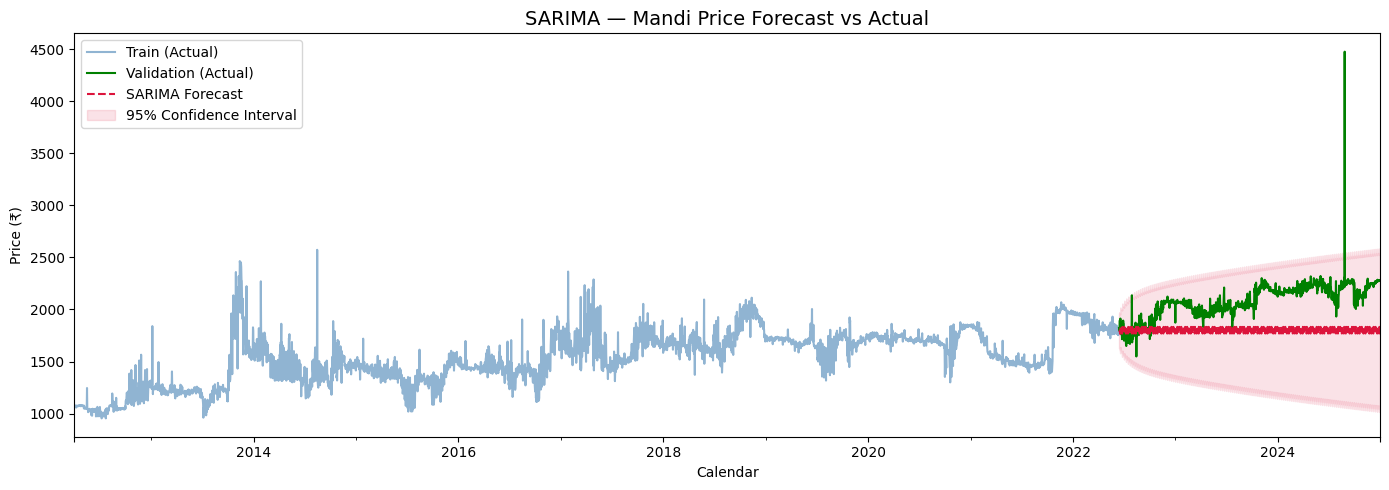

Plot saved → sarima_forecast.png


In [3]:
import pandas as pd
import numpy as np
import warnings
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, median_absolute_error, max_error
)

warnings.filterwarnings('ignore')

TARGET = 'Mandi Modal Price (AgMarknet)'

# ── 1. Load & Prepare ─────────────────────────────────────────────────────────
print("Loading data...")
df = pd.read_excel('../train.ods', engine='odf')
df['Calendar'] = pd.to_datetime(df['Calendar'])
df = df.sort_values('Calendar').reset_index(drop=True)
df = df.set_index('Calendar')

price_series = df[TARGET].asfreq('D')          # Set daily frequency
price_series = price_series.interpolate()      # Fill any missing dates linearly

print(f"Series length : {len(price_series)} days")
print(f"Date range    : {price_series.index[0].date()} → {price_series.index[-1].date()}")
print(f"Price range   : ₹{price_series.min():.0f} – ₹{price_series.max():.0f}")

# ── 2. Stationarity Check (ADF Test) ─────────────────────────────────────────
def check_stationarity(series, label="Series"):
    result = adfuller(series.dropna())
    print(f"\n── ADF Test: {label} ──")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  → {'STATIONARY ✓' if result[1] < 0.05 else 'NON-STATIONARY ✗ (differencing needed)'}")
    return result[1] < 0.05

is_stationary = check_stationarity(price_series, "Original Price")
if not is_stationary:
    check_stationarity(price_series.diff().dropna(), "1st Difference")

# ── 3. Plot ACF / PACF to visualise seasonality ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(price_series.dropna(),  ax=axes[0], lags=60, title='ACF  — helps choose q, Q')
plot_pacf(price_series.dropna(), ax=axes[1], lags=60, title='PACF — helps choose p, P')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=120)
plt.show()
print("\nACF/PACF plot saved → acf_pacf.png")

# ── 4. Grid Search for Best SARIMA Parameters ────────────────────────────────
# Seasonal period: 7 = weekly pattern (most common for daily mandi prices)
# Change to 30 if you see strong monthly seasonality in the ACF plot
SEASONAL_PERIOD = 7

print(f"\nRunning grid search (seasonal period = {SEASONAL_PERIOD})...")
print("This may take a few minutes...\n")

# Search space — keep small to avoid hours of compute
p_values = [0, 1, 2]
d_values = [0, 1]        # 1 if non-stationary, 0 if stationary
q_values = [0, 1, 2]
P_values = [0, 1]        # Seasonal AR
D_values = [0, 1]        # Seasonal differencing
Q_values = [0, 1]        # Seasonal MA

best_aic   = np.inf
best_order = None
best_sorder= None
results_log= []

combos = list(itertools.product(p_values, d_values, q_values,
                                P_values, D_values, Q_values))
print(f"Testing {len(combos)} parameter combinations...")

for p, d, q, P, D, Q in combos:
    try:
        model = SARIMAX(
            price_series,
            order=(p, d, q),
            seasonal_order=(P, D, Q, SEASONAL_PERIOD),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False)
        results_log.append({
            'order': (p,d,q), 'seasonal': (P,D,Q,SEASONAL_PERIOD),
            'AIC': fit.aic, 'BIC': fit.bic
        })
        if fit.aic < best_aic:
            best_aic    = fit.aic
            best_order  = (p, d, q)
            best_sorder = (P, D, Q, SEASONAL_PERIOD)
    except Exception:
        continue

print(f"\n✓ Best SARIMA order          : {best_order}")
print(f"✓ Best Seasonal order        : {best_sorder}")
print(f"✓ Best AIC                   : {best_aic:.2f}")

# Show top 5 candidates
results_df = pd.DataFrame(results_log).sort_values('AIC').head(5)
print("\nTop 5 parameter combinations:")
print(results_df.to_string(index=False))

# ── 5. Chronological Train / Validation Split (80/20) ────────────────────────
split_idx   = int(len(price_series) * 0.8)
train_series = price_series.iloc[:split_idx]
val_series   = price_series.iloc[split_idx:]

print(f"\nTrain: {len(train_series)} rows | Val: {len(val_series)} rows")

# ── 6. Train Final Model on Train Split ───────────────────────────────────────
print(f"\nFitting SARIMA{best_order}×{best_sorder} on training data...")
sarima_model = SARIMAX(
    train_series,
    order=best_order,
    seasonal_order=best_sorder,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# ── 7. Validate: One-step-ahead forecast on validation set ────────────────────
# get_prediction gives in-sample + out-of-sample forecasts with confidence intervals
forecast_obj = sarima_fit.get_forecast(steps=len(val_series))
predictions  = forecast_obj.predicted_mean
conf_int     = forecast_obj.conf_int(alpha=0.05)   # 95% confidence interval

predictions.index = val_series.index   # Align index for plotting

# ── 8. Metrics ────────────────────────────────────────────────────────────────
mae   = mean_absolute_error(val_series, predictions)
rmse  = np.sqrt(mean_squared_error(val_series, predictions))
mape  = mean_absolute_percentage_error(val_series, predictions) * 100
medae = median_absolute_error(val_series, predictions)
max_e = max_error(val_series, predictions)
r2    = r2_score(val_series, predictions)

print("\n── SARIMA METRICS (Validation Set) ──────────────────────────")
print(f"MAE (Mean Absolute Error):        ₹{mae:.2f}")
print(f"MedAE (Median Absolute Error):    ₹{medae:.2f}")
print(f"Max Error (Worst Prediction):     ₹{max_e:.2f}")
print(f"RMSE:                             ₹{rmse:.2f}")
print(f"MAPE:                             {mape:.2f}%")
print(f"R-squared:                        {r2:.4f}")

# ── 9. Plot Actual vs Predicted ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
train_series.plot(ax=ax, label='Train (Actual)',      color='steelblue',  alpha=0.6)
val_series.plot(  ax=ax, label='Validation (Actual)', color='green',      linewidth=1.5)
predictions.plot( ax=ax, label='SARIMA Forecast',     color='crimson',    linewidth=1.5, linestyle='--')
ax.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='crimson', alpha=0.12, label='95% Confidence Interval'
)
ax.set_title('SARIMA — Mandi Price Forecast vs Actual', fontsize=14)
ax.set_ylabel('Price (₹)')
ax.legend()
plt.tight_layout()
plt.savefig('sarima_forecast.png', dpi=120)
plt.show()
print("Plot saved → sarima_forecast.png")


In [4]:

# ── 10. Submission Function ───────────────────────────────────────────────────
def generate_sarima_submission(test_filepath, fitted_model, full_price_series):
    """
    Generates submission by retraining on ALL data, then forecasting forward.
    SARIMA doesn't need feature engineering — it forecasts purely from the series.
    """
    print(f"\nProcessing test file: {test_filepath}")

    df_test = pd.read_excel(test_filepath, engine='odf')
    df_test['Calendar'] = pd.to_datetime(df_test['Calendar'])
    df_test = df_test.sort_values('Calendar').reset_index(drop=True)
    n_forecast = len(df_test)

    # Retrain on full history so the model has maximum context
    print(f"Retraining SARIMA on full dataset ({len(full_price_series)} rows)...")
    final_model = SARIMAX(
        full_price_series,
        order=best_order,
        seasonal_order=best_sorder,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    # Forecast forward
    forecast = final_model.get_forecast(steps=n_forecast)
    preds    = forecast.predicted_mean.values
    ci       = forecast.conf_int(alpha=0.05)

    submission = pd.DataFrame({
        'Calendar'          : df_test['Calendar'],
        'Predicted_Price'   : preds,
        'Lower_95CI'        : ci.iloc[:, 0].values,
        'Upper_95CI'        : ci.iloc[:, 1].values,
    })
    submission.to_csv('submission_sarima.csv', index=False)

    print(f"✓ {n_forecast} predictions saved → submission_sarima.csv")
    print(f"  Price range : ₹{preds.min():.2f} – ₹{preds.max():.2f}")
    print(f"  Mean price  : ₹{preds.mean():.2f}")
    return submission


# Run when judge file is available
final_predictions = generate_sarima_submission('../judge_test.ods', sarima_fit, price_series)


Processing test file: ../judge_test.ods
Retraining SARIMA on full dataset (4658 rows)...
✓ 424 predictions saved → submission_sarima.csv
  Price range : ₹2211.92 – ₹2296.85
  Mean price  : ₹2233.41


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    max_error,
    explained_variance_score
)

print("Loading test results from submission.csv...")

# 1. Load the updated submission file
df_results = pd.read_csv('submission_sarima.csv')

# Saftey check: Drop any rows where the Actual_Price might be accidentally blank
df_results = df_results.dropna(subset=['Actual_Price', 'Predicted_Price'])

# 2. Extract the actual and predicted columns
y_actual = df_results['Actual_Price']
y_pred = df_results['Predicted_Price']

# 3. Calculate all the metrics
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mape = mean_absolute_percentage_error(y_actual, y_pred) * 100  # Convert to percentage
medae = median_absolute_error(y_actual, y_pred)
max_err = max_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)
evs = explained_variance_score(y_actual, y_pred)

# 4. Print the final scorecard
print("\n--- FINAL TEST SET METRICS (submission.csv) ---")
print(f"MAE (Mean Absolute Error):        ₹{mae:.2f}")
print(f"MedAE (Median Absolute Error):    ₹{medae:.2f}")
print(f"Max Error (Worst Prediction):     ₹{max_err:.2f}")
print('-' * 48)
print(f"RMSE (Root Mean Squared Error):   ₹{rmse:.2f}")
print(f"MAPE (Mean Abs Percentage Error): {mape:.2f}%")
print('-' * 48)
print(f"R-squared:                        {r2:.4f}")
print(f"Explained Variance Score:         {evs:.4f}")

Loading test results from submission.csv...

--- FINAL TEST SET METRICS (submission.csv) ---
MAE (Mean Absolute Error):        ₹89.68
MedAE (Median Absolute Error):    ₹66.83
Max Error (Worst Prediction):     ₹448.78
------------------------------------------------
RMSE (Root Mean Squared Error):   ₹121.14
MAPE (Mean Abs Percentage Error): 4.25%
------------------------------------------------
R-squared:                        -0.1585
Explained Variance Score:         0.0211
